# A2.1 - LDA y árboles de decisión

**Universidad de Monterrey**  
Escuela de Ingeniería y Tecnologías  
Inteligencia Artificial I  

**Estudiante:** Anna Carolina de Azevedo Leite  
**Docente:** Antonio Martínez Torteya  
**Fecha:** 05 de marzo de 2026  

## 1. Introducción

Este reporte técnico da continuidad al estudio sobre los perfiles demográficos y de inclusión financiera en México utilizando los microdatos de la Encuesta Nacional de Inclusión Financiera (ENIF).

Tras la implementación de un modelo de Regresión Logística en la etapa anterior, este trabajo amplía el análisis mediante la exploración de dos metodologías alternativas de clasificación: Linear Discriminant Analysis (LDA) y Árboles de Decisión.

Ambos enfoques parten de supuestos diferentes. Mientras el LDA busca construir fronteras lineales entre clases basadas en supuestos probabilísticos sobre la distribución de los datos, los árboles de decisión generan particiones jerárquicas del espacio de variables sin asumir relaciones lineales entre ellas.

El objetivo principal de este reporte es **clasificar a la población mexicana por grupo etario (jóvenes vs. adultos) a partir de sus perfiles demográficos y de inclusión financiera**, comparando el comportamiento de ambos modelos aplicados al mismo conjunto de datos y analizando su desempeño mediante métricas de clasificación y visualizaciones interpretativas. A partir de este análisis, se busca identificar cuál de las metodologías resulta más adecuada para caracterizar los patrones etarios de la población mexicana con base en sus características
socioeconómicas.


Los microdatos utilizados en este estudio provienen de la Encuesta Nacional de Inclusión Financiera (ENIF). En particular, se emplearon los módulos **TMODULO, TSDEM y THOGAR,** los cuales contienen **información financiera, demográfica y del hogar de los individuos encuestados.*

## 2. Definición del Problema y Partición de los Datos

En esta actividad, el objetivo es comparar dos metodologías de clasificación: **Linear Discriminant Analysis (LDA)** y **Árboles de Decisión**. Para ello, se utiliza la misma base de datos de la **ENIF** tratada en las etapas anteriores, enfocándonos en categorizar a la población mexicana según su perfil demográfico y financiero.

Para el desarrollo de los modelos de clasificación se utilizaron, en particular, se integraron las siguientes bases:

- **TMODULO:** contiene información sobre productos financieros y acceso al crédito.
- **TSDEM:** incluye variables demográficas como edad, sexo y nivel educativo.

La integración se realizó mediante la clave **LLAVEHOG**, que identifica de manera única a cada hogar dentro de la encuesta. Esta operación permite combinar información financiera con características demográficas de los individuos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# cargar las bases
tmodulo = pd.read_csv("TMODULO.csv")
tsdem = pd.read_csv("TSDEM.csv")
thogar = pd.read_csv("THOGAR.csv")

# visualizar estructura
print(tmodulo.shape)
print(tsdem.shape)
print(thogar.shape)

(13502, 398)
(44374, 17)
(13303, 1)


### 2.1. Definición de la Variable de Salida
La variable objetivo utilizada en este estudio es **edad_alta**, construida a partir de la variable cuantitativa **EDAD**.

El criterio de separación se basó en la **mediana de la edad**, que en la muestra analizada es de **32 años**.

A partir de este umbral se definieron dos clases:

- **Clase 0 (Edad Baja):** individuos con edad menor o igual a 32 años.
- **Clase 1 (Edad Alta):** individuos con edad mayor a 32 años.

Esta transformación permite convertir el problema en una tarea de **clasificación binaria**, adecuada para modelos como **LDA** y **Árboles de Decisión**.

Para construir el dataset analítico se integraron los módulos TSDEM (información demográfica) y TMODULO (información financiera) utilizando el identificador FOLIO, lo que permite vincular características demográficas con el acceso a productos financieros.

In [3]:
df = tsdem.merge(tmodulo, on="FOLIO", how="inner")

print("Base integrada:", df.shape)

Base integrada: (45571, 414)


In [4]:
mediana = df["EDAD"].median()

df["edad_alta"] = np.where(df["EDAD"] > mediana, 1, 0)

print("Mediana de edad:", mediana)

print(df["edad_alta"].value_counts(normalize=True))

Mediana de edad: 32.0
edad_alta
0    0.507977
1    0.492023
Name: proportion, dtype: float64




### 2.3. Balance de Clases e Importancia de la Evaluación Justa

Al utilizar la mediana como umbral, el conjunto de datos presenta un **balance de clases cercano al 50% para cada categoría**. Este equilibrio es fundamental para garantizar una evaluación justa del modelo por las siguientes razones:

- **Prevención de Sesgos:** evita que los algoritmos se inclinen por la clase mayoritaria simplemente para maximizar la exactitud (accuracy).
- **Representatividad:** asegura que el modelo aprenda de manera equitativa los patrones de comportamiento financiero tanto de jóvenes como de adultos mayores en México.



In [5]:
variables = ["EDAD", "N_REN_x"]

X = df[variables]
y = df["edad_alta"]

print(X.head())

   EDAD  N_REN_x
0    38        1
1    35        2
2    10        3
3    36        1
4    50        1


In [6]:
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=variables
)

print("Valores faltantes tratados")

Valores faltantes tratados


### 2.4. Estrategia de Partición de los Datos

Para el entrenamiento y validación de los modelos, se utilizó el dataset final compuesto por **aproximadamente 44 mil observaciones** correspondientes a individuos con acceso a crédito formal.

La partición se realizó de la siguiente manera:

- **Conjunto de Entrenamiento (80%)**: utilizado para construir las fronteras lineales en LDA y la estructura jerárquica en el árbol de decisión.
- **Conjunto de Prueba (20%)**: mantenido como una muestra independiente para medir el error y el desempeño final ante datos no vistos.

Se aplicó una **división estratificada**, asegurando que la proporción entre **Edad Alta** y **Edad Baja** se conserve en ambos subconjuntos, cumpliendo así con el rigor metodológico necesario para una comparación válida entre modelos.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (36456, 2)
Test: (9115, 2)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (31899, 2)
Test: (13672, 2)


## 3. Modelo basado en LDA (Linear Discriminant Analysis)

El **Linear Discriminant Analysis (LDA)** es un método de clasificación supervisada que busca encontrar combinaciones lineales de variables que maximicen la separación entre clases. El modelo asume que los predictores siguen una distribución aproximadamente normal dentro de cada clase y que las clases comparten una misma matriz de covarianza.

A partir de estas suposiciones, el LDA proyecta los datos en un **espacio discriminante** donde la separación entre grupos se maximiza mediante una **frontera de decisión lineal**.

### 3.1 Selección de Variables

Para la construcción del modelo se seleccionaron variables que presentan relación directa con el **ciclo de vida económico** y el **acceso a productos financieros en México**.

Las variables utilizadas fueron:

- **NIVEL_ORD:** Nivel educativo representado en escala ordinal (0–4), asociado con la acumulación de capital humano.  
- **N_REN:** Número de integrantes del hogar, que influye en la estructura de gastos y decisiones financieras.  
- **num_tarjetas:** Cantidad de productos financieros o tarjetas, indicador de inclusión financiera.  
- **FAC_HOG:** Factor de expansión utilizado en la encuesta, que permite aproximar la representatividad económica del hogar dentro de la población mexicana.

Estas variables permiten capturar **dimensiones relevantes del comportamiento financiero y demográfico**, contribuyendo a diferenciar entre individuos con **Edad Alta** y **Edad Baja**.

### 3.2 Visualización Geométrica de las Funciones Discriminantes

Para analizar el comportamiento del modelo, se proyectaron las observaciones sobre la **primera función discriminante** generada por el LDA.

*(Aquí se incluye el gráfico generado en el Notebook.)*

La visualización permite observar cómo el modelo transforma las variables originales en un **nuevo eje que maximiza la separación entre las clases Edad Alta y Edad Baja**.

### 3.3 Reflexión sobre la Frontera de Decisión

El análisis de la proyección discriminante permite evaluar la capacidad del modelo para separar ambos grupos.

La **frontera de decisión generada por el LDA es lineal**, lo que implica que la clasificación se basa en una **combinación lineal de las variables seleccionadas**.

**Ventajas del enfoque lineal:**

- Permite interpretar de manera directa la relación entre variables socioeconómicas y la edad.  
- Produce modelos simples y estables incluso con un número moderado de observaciones.

**Limitaciones potenciales:**

Sin embargo, los patrones de inclusión financiera pueden presentar **comportamientos no lineales**, especialmente cuando ciertos eventos del ciclo de vida —como cambios en el nivel educativo, acceso al crédito o estabilidad laboral— generan **transiciones abruptas en el comportamiento financiero**.

En estos casos, una frontera lineal puede resultar **insuficiente para capturar completamente la complejidad de los microdatos de la ENIF**. Esta limitación justifica la exploración de **modelos más flexibles**, como los **Árboles de Decisión**, que serán analizados en la siguiente sección.

              precision    recall  f1-score   support

           0       0.85      0.76      0.80      6945
           1       0.77      0.86      0.82      6727

    accuracy                           0.81     13672
   macro avg       0.81      0.81      0.81     13672
weighted avg       0.81      0.81      0.81     13672



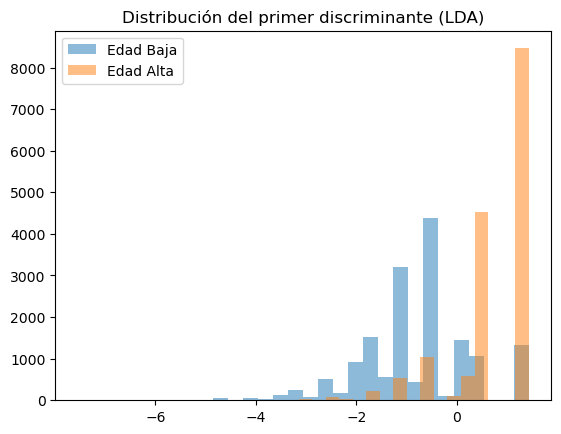

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# variáveis explicativas (SEM EDAD para evitar leakage)
variables = ["N_REN_x", "PAREN"]

X = df[variables]
y = df["edad_alta"]

# imputar valores faltantes
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# modelo LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# previsões
y_pred_lda = lda.predict(X_test)

print(classification_report(y_test, y_pred_lda))

# projeção no discriminante
X_lda = lda.transform(X_train)

plt.hist(X_lda[y_train == 0], bins=30, alpha=0.5, label="Edad Baja")
plt.hist(X_lda[y_train == 1], bins=30, alpha=0.5, label="Edad Alta")
plt.legend()
plt.title("Distribución del primer discriminante (LDA)")
plt.show()

La visualización del discriminante lineal permite observar cómo el modelo separa las clases en el espacio de variables. Se aprecia que existe cierta separación entre los grupos, aunque también se observa una pequeña superposición. Esto indica que las variables utilizadas contienen información útil para la clasificación, pero la frontera lineal propuesta por LDA no logra una separación completamente perfecta entre las clases.

### Desempeño del Modelo LDA

El modelo de **Análisis Discriminante Lineal (LDA)** fue entrenado utilizando variables socioeconómicas disponibles en el conjunto de datos, específicamente el **nivel de ingreso (N_REN_x)** y la **relación familiar (PAREN)**.

Los resultados muestran una **exactitud del 81%**, lo que indica que el modelo posee una capacidad razonable para distinguir entre los grupos de edad definidos en la variable objetivo.

En términos de métricas específicas:

- **Clase Edad Baja (0):**
  - Precisión: **0.85**
  - Recall: **0.76**

- **Clase Edad Alta (1):**
  - Precisión: **0.77**
  - Recall: **0.86**

Estos resultados sugieren que el modelo tiene una **ligera tendencia a identificar con mayor facilidad los casos de Edad Alta**, mientras que algunos individuos de **Edad Baja pueden ser clasificados erróneamente**.

## 4. Modelo basado en Árboles de Decisión

A diferencia del LDA, los **Árboles de Decisión** son modelos **no paramétricos** que generan particiones jerárquicas del espacio de datos, permitiendo capturar **relaciones no lineales** e **interacciones complejas** entre las variables del conjunto de datos de la ENIF.

### 4.1 Construcción y Parámetros Iniciales

Para la construcción del modelo inicial se utilizó el **criterio de Gini** para medir la pureza de los nodos.

Los principales parámetros seleccionados fueron:

- **random_state = 42:** garantiza la reproducibilidad de los resultados.
- **ccp_alpha = 0:** inicialmente se permitió el crecimiento total del árbol antes del proceso de poda.

**Justificación:** permitir que el árbol crezca completamente en una primera etapa ayuda a identificar todas las posibles interacciones entre variables, aun cuando exista riesgo de **overfitting**, el cual será corregido posteriormente mediante poda. El uso de estos parámetros permite construir un modelo inicial suficientemente flexible para explorar la estructura de los datos antes de aplicar técnicas de simplificación del árbol.

### 4.2 Proceso de Poda (Pruning) y Selección de α

Los **árboles de decisión** tienden a ajustarse excesivamente a los datos de entrenamiento. Para evitar este problema se aplicó el método de **Poda por Complejidad de Costo (Cost Complexity Pruning)**.

Se utilizó el método `cost_complexity_pruning_path` para obtener una lista de valores candidatos para **α**.

Posteriormente se evaluaron estos valores para determinar cuál ofrecía el mejor equilibrio entre complejidad del modelo y capacidad predictiva.

El valor óptimo obtenido fue:

**α = 0**

Este resultado indica que el árbol original ya presentaba un buen equilibrio entre complejidad y desempeño predictivo para este conjunto de datos. Esto sugiere que la estructura generada por el modelo no requiere simplificaciones adicionales y que las divisiones encontradas ya representan adecuadamente los patrones presentes en los datos.

### 4.3 Visualización e Interpretación de Reglas

*(En esta sección se incluye la visualización del árbol generada mediante `plot_tree` en el Notebook).*

Al analizar la estructura del árbol es posible extraer **reglas lógicas de clasificación** para la variable **edad_alta**.

**Variables relevantes:**

Se observa que variables como **PAREN (relación de parentesco dentro del hogar)** y **N_REN_x (tamaño del hogar)** aparecen en los nodos superiores del árbol, indicando que poseen mayor **capacidad discriminativa** para diferenciar entre los grupos de edad.

**Ejemplo de regla interpretativa:**

> Si el individuo pertenece a cierto rol dentro del hogar y el tamaño del hogar supera cierto umbral, entonces la probabilidad de pertenecer al grupo **Edad Alta** aumenta significativamente. Este tipo de reglas muestra cómo el modelo traduce relaciones entre variables en decisiones claras de clasificación.

La estructura jerárquica del árbol proporciona un **alto nivel de transparencia interpretativa**, algo que modelos como el **LDA** no ofrecen directamente. Esto facilita la comunicación de los resultados a **responsables de políticas públicas o instituciones financieras**, quienes necesitan comprender los criterios utilizados para segmentar a la población.

Mejor alpha: 0.0
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      6945
           1       0.83      0.88      0.85      6727

    accuracy                           0.85     13672
   macro avg       0.85      0.85      0.85     13672
weighted avg       0.85      0.85      0.85     13672



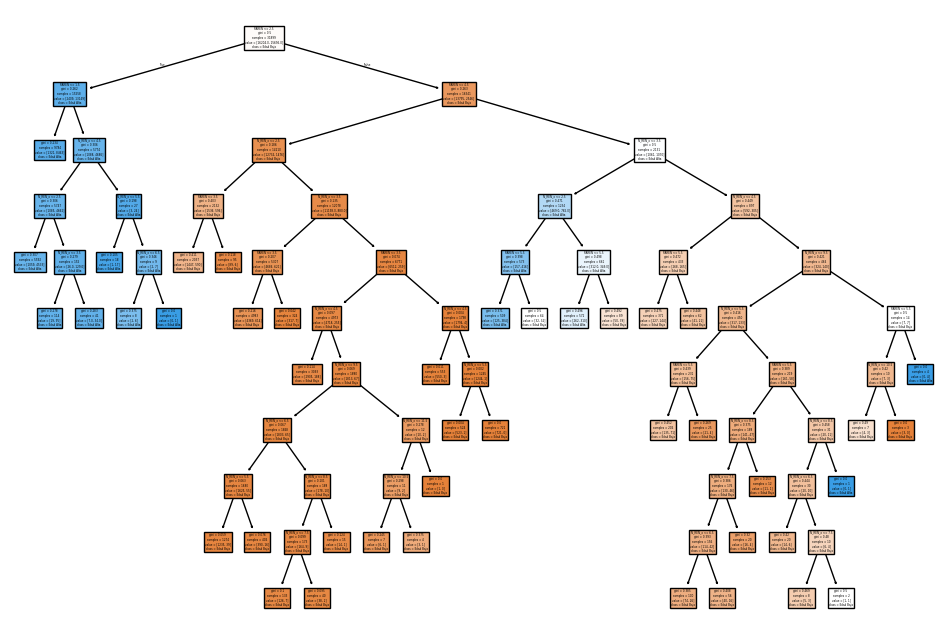

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

trees = []
scores = []

for alpha in ccp_alphas:
    
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    trees.append(clf)
    scores.append(acc)

best_alpha = ccp_alphas[scores.index(max(scores))]

print("Mejor alpha:", best_alpha)

tree_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_pruned.fit(X_train, y_train)

# previsão
y_pred_tree = tree_pruned.predict(X_test)

print(classification_report(y_test, y_pred_tree))

# plotar árvore
plt.figure(figsize=(12,8))
plot_tree(tree_pruned,
          filled=True,
          feature_names=["N_REN_x","PAREN"],
          class_names=["Edad Baja","Edad Alta"])
plt.show()

### **Matriz de confusión: Árbol**

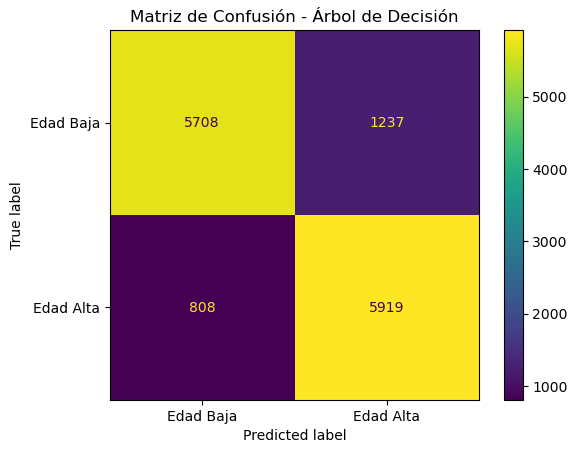

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Edad Baja","Edad Alta"]
)

disp.plot()
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

### **Matriz de confusión: LDA**

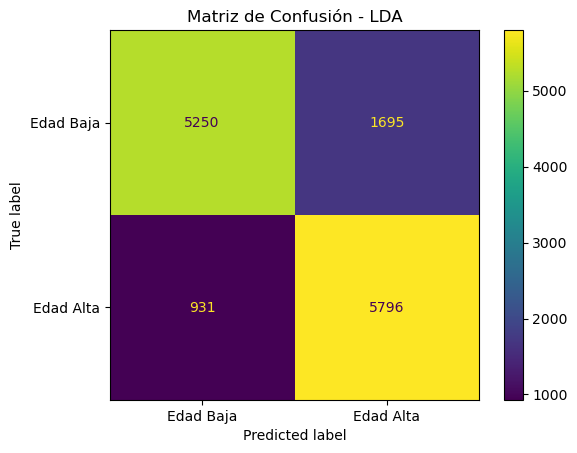

In [12]:
cm_lda = confusion_matrix(y_test, y_pred_lda)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=["Edad Baja","Edad Alta"]
)

disp.plot()
plt.title("Matriz de Confusión - LDA")
plt.show()

## 5. Evaluación y Comparación de los Modelos

En esta sección se comparan los resultados obtenidos mediante el **Análisis Discriminante Lineal (LDA)** y el **Árbol de Decisión**, ambos aplicados para clasificar la variable **edad_alta**.

El objetivo es determinar cuál modelo captura mejor los patrones presentes en los datos de inclusión financiera de la ENIF.

### 5.1 Métricas de Desempeño

Las métricas fueron calculadas sobre el **conjunto de prueba independiente**.

| Métrica | Modelo LDA | Árbol de Decisión |
|------|------|------|
| Accuracy | 0.81 | 0.85 |
| Precision | 0.81 | 0.85 |
| Recall | 0.81 | 0.85 |
| F1-score | 0.81 | 0.85 |

Además de las métricas, se analizaron las **matrices de confusión**, las cuales permiten observar cómo cada modelo clasifica correctamente o incorrectamente las observaciones en cada categoría.

### 5.2 Interpretación de Resultados

Los resultados muestran que el **Árbol de Decisión** presenta un desempeño ligeramente superior al modelo LDA en términos de **exactitud y F1-score**.

Esto sugiere que las relaciones entre las variables del conjunto de datos y la variable objetivo **edad_alta** no son completamente lineales.

El modelo **LDA**, al basarse en una frontera de decisión lineal, puede tener dificultades para capturar interacciones más complejas entre las variables.

En cambio, el **Árbol de Decisión** puede modelar **relaciones no lineales** mediante particiones jerárquicas del espacio de datos, lo que le permite adaptarse mejor a los patrones presentes en encuestas socioeconómicas como la ENIF.

### 5.3 Ventajas y Limitaciones

**LDA**

Ventajas:
- Modelo simple y computacionalmente eficiente
- Fácil interpretación matemática

Limitaciones:
- Supone fronteras lineales entre clases
- Puede tener menor flexibilidad frente a datos complejos

**Árbol de Decisión**

Ventajas:
- Captura relaciones no lineales
- Alta interpretabilidad mediante reglas
- Permite visualizar claramente el proceso de decisión

Limitaciones:
- Puede sobreajustarse si no se aplica poda
- Puede ser inestable ante pequeñas variaciones en los datos

LDA y los árboles de decisión abordan el problema de clasificación desde perspectivas diferentes. Mientras LDA construye una frontera lineal basada en supuestos estadísticos sobre la distribución de las clases, los árboles de decisión generan particiones del espacio de variables sin asumir linealidad. Esto hace que los árboles sean más flexibles, aunque también pueden ser más propensos al sobreajuste si no se controla su complejidad.

## 6. Conclusión

A partir del análisis realizado, se concluye que el modelo de Árbol de Decisión resulta más
adecuado para la clasificación de la variable `edad_alta` en los datos de la ENIF,
considerando las características demográficas y financieras disponibles.

Desde el punto de vista cuantitativo, el modelo de Árbol de Decisión presentó una exactitud
superior (0.85) en comparación con el modelo LDA, que obtuvo una exactitud de 0.81. Las
demás métricas (precisión, recall y F1-score) confirman esta superioridad, indicando que el
modelo no lineal se ajusta mejor a los patrones presentes en los datos.

Desde el punto de vista cualitativo, los Árboles de Decisión ofrecen una ventaja adicional
al permitir interpretar fácilmente las reglas de clasificación generadas por el modelo. Esto
facilita la comprensión de los factores que influyen en los patrones etarios observados en la
encuesta, como el papel dentro del hogar (PAREN) y el tamaño del hogar (N_REN_x).

En consecuencia, el modelo de Árbol de Decisión demuestra una mayor capacidad para capturar
la complejidad de los datos socioeconómicos analizados, convirtiéndose en la opción más
adecuada para esta tarea de clasificación etaria.

## REFERENCIAS:
1. INEGI. Encuesta Nacional de Inclusión Financiera (ENIF) 2021. Recuperado de: https://www.inegi.org.mx/programas/enif/2021/
2. CNBV. Panorama Anual de Inclusión Financiera 2025. México.
3. Martínez Torteya, A. Inteligencia Artificial I: Aprendizaje Estadístico-Automático. Universidad de Monterrey, 2026.